# Joint POD-rank and surrogate selection

## Purpose

This notebook selects the POD rank and coefficient surrogate jointly for the
coarse-grained rotating-drum volume-fraction model.

A model with more POD modes has a lower projection error, but its higher-order
coefficients may be noisy and difficult to predict. Consequently, the rank
capturing the most snapshot energy is not necessarily the rank giving the best
end-to-end predictions.

The experiment compares several POD ranks using training-only cross-validation.

For every validation fold:

1. the mean field is calculated from the fitting simulations only;
2. the POD basis is calculated from the fitting simulations only;
3. the coefficient surrogate is fitted using the fitting simulations only;
4. coefficients are predicted from the held-out parameter values;
5. complete held-out fields are reconstructed;
6. projection and surrogate errors are recorded separately.

The ten supplied test simulations remain untouched until the final model and
rank have been selected.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.exceptions import ConvergenceWarning
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings(
    "ignore",
    category=ConvergenceWarning,
)


def find_project_root(start: Path) -> Path:
    """Locate the repository root from anywhere inside the project."""
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "data").exists()
            and (candidate / "notebooks").exists()
            and (candidate / "results").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the msc-rom-particle-systems repository."
    )


CURRENT_DIR = Path.cwd()
PROJECT_ROOT = find_project_root(CURRENT_DIR)

PROCESSED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "cg_phi_small_dataset.npz"
)

FIGURE_DIR = PROJECT_ROOT / "results" / "figures"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

if not PROCESSED_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Processed dataset was not found:\n{PROCESSED_DATA_PATH}"
    )

with np.load(
    PROCESSED_DATA_PATH,
    allow_pickle=False,
) as data:
    x_grid = data["x"]
    z_grid = data["z"]
    train_parameters = data["train_parameters"]
    test_parameters = data["test_parameters"]
    train_snapshot_matrix = data["train_snapshots"]
    test_snapshot_matrix = data["test_snapshots"]

print("Python executable:", sys.executable)
print("Project root:", PROJECT_ROOT)
print("Training parameters:", train_parameters.shape)
print("Training snapshots:", train_snapshot_matrix.shape)
print("Untouched test parameters:", test_parameters.shape)
print("Untouched test snapshots:", test_snapshot_matrix.shape)

assert train_parameters.shape == (100,)
assert train_snapshot_matrix.shape == (10000, 100)
assert test_parameters.shape == (10,)
assert test_snapshot_matrix.shape == (10000, 10)
assert np.isfinite(train_snapshot_matrix).all()
assert np.isfinite(test_snapshot_matrix).all()

print("\nDataset checks passed.")

Python executable: /Users/rallen/Documents/msc-rom-particle-systems/.venv/bin/python
Project root: /Users/rallen/Documents/msc-rom-particle-systems
Training parameters: (100,)
Training snapshots: (10000, 100)
Untouched test parameters: (10,)
Untouched test snapshots: (10000, 10)

Dataset checks passed.


In [2]:
candidate_ranks = np.array(
    [
        1,
        2,
        3,
        4,
        6,
        8,
        10,
        15,
        20,
    ],
    dtype=int,
)

number_of_folds = 5

all_training_indices = np.arange(
    train_parameters.size
)

# Keep the two parameter-range endpoints in every fitting set.
# Validation therefore measures interpolation, not extrapolation.
internal_indices = np.arange(
    1,
    train_parameters.size - 1,
)

validation_folds = [
    internal_indices[
        np.arange(
            internal_indices.size
        ) % number_of_folds
        == fold_index
    ]
    for fold_index in range(number_of_folds)
]

print("Candidate POD ranks:")
print(candidate_ranks)

print("\nValidation folds:")

for fold_number, validation_indices in enumerate(
    validation_folds,
    start=1,
):
    fitting_indices = np.setdiff1d(
        all_training_indices,
        validation_indices,
    )

    print(
        f"  Fold {fold_number}: "
        f"{fitting_indices.size} fitting cases, "
        f"{validation_indices.size} validation cases, "
        f"validation range "
        f"{train_parameters[validation_indices].min():.6f} to "
        f"{train_parameters[validation_indices].max():.6f}"
    )

validation_union = np.concatenate(
    validation_folds
)

assert np.unique(
    validation_union
).size == internal_indices.size

assert not np.any(
    validation_union == 0
)

assert not np.any(
    validation_union == train_parameters.size - 1
)

assert candidate_ranks.max() < min(
    len(fitting_indices)
    for fitting_indices in [
        np.setdiff1d(
            all_training_indices,
            validation_indices,
        )
        for validation_indices in validation_folds
    ]
)

print("\nRank and validation-fold checks passed.")

Candidate POD ranks:
[ 1  2  3  4  6  8 10 15 20]

Validation folds:
  Fold 1: 80 fitting cases, 20 validation cases, validation range 1.010101 to 1.969697
  Fold 2: 80 fitting cases, 20 validation cases, validation range 1.020202 to 1.979798
  Fold 3: 80 fitting cases, 20 validation cases, validation range 1.030303 to 1.989899
  Fold 4: 81 fitting cases, 19 validation cases, validation range 1.040404 to 1.949495
  Fold 5: 81 fitting cases, 19 validation cases, validation range 1.050505 to 1.959596

Rank and validation-fold checks passed.


In [3]:
fold_data = []

for fold_number, validation_indices in enumerate(
    validation_folds,
    start=1,
):
    fitting_indices = np.setdiff1d(
        all_training_indices,
        validation_indices,
    )

    fitting_parameters = train_parameters[
        fitting_indices
    ]

    validation_parameters = train_parameters[
        validation_indices
    ]

    fitting_snapshots = train_snapshot_matrix[
        :,
        fitting_indices,
    ]

    validation_snapshots = train_snapshot_matrix[
        :,
        validation_indices,
    ]

    # Calculated from fitting simulations only.
    fold_mean = fitting_snapshots.mean(
        axis=1,
        keepdims=True,
    )

    centred_fitting_snapshots = (
        fitting_snapshots
        - fold_mean
    )

    (
        fold_modes,
        fold_singular_values,
        fold_right_vectors,
    ) = np.linalg.svd(
        centred_fitting_snapshots,
        full_matrices=False,
    )

    fold_energy = np.cumsum(
        fold_singular_values**2
    ) / np.sum(
        fold_singular_values**2
    )

    fold_data.append(
        {
            "fold_number": fold_number,
            "fitting_indices": fitting_indices,
            "validation_indices": validation_indices,
            "fitting_parameters": fitting_parameters,
            "validation_parameters": validation_parameters,
            "fitting_snapshots": fitting_snapshots,
            "validation_snapshots": validation_snapshots,
            "mean_snapshot": fold_mean,
            "centred_fitting_snapshots": (
                centred_fitting_snapshots
            ),
            "modes": fold_modes,
            "singular_values": (
                fold_singular_values
            ),
            "cumulative_energy": fold_energy,
        }
    )

    print(
        f"Prepared fold {fold_number}: "
        f"{fitting_snapshots.shape[1]} fitting fields, "
        f"{validation_snapshots.shape[1]} validation fields"
    )

print(
    "\nNumber of prepared folds:",
    len(fold_data),
)

assert len(fold_data) == number_of_folds

for fold in fold_data:
    assert fold["modes"].shape[0] == 10000
    assert np.isfinite(
        fold["singular_values"]
    ).all()

print("Leakage-free fold POD checks passed.")

Prepared fold 1: 80 fitting fields, 20 validation fields
Prepared fold 2: 80 fitting fields, 20 validation fields
Prepared fold 3: 80 fitting fields, 20 validation fields
Prepared fold 4: 81 fitting fields, 19 validation fields
Prepared fold 5: 81 fitting fields, 19 validation fields

Number of prepared folds: 5
Leakage-free fold POD checks passed.


In [4]:
def predict_linear_coefficients(
    fitting_parameters: np.ndarray,
    fitting_coefficients: np.ndarray,
    query_parameters: np.ndarray,
) -> np.ndarray:
    """Predict each POD coefficient using linear interpolation."""
    sorting_indices = np.argsort(
        fitting_parameters
    )

    sorted_parameters = fitting_parameters[
        sorting_indices
    ]

    sorted_coefficients = fitting_coefficients[
        :,
        sorting_indices,
    ]

    return np.vstack(
        [
            np.interp(
                query_parameters,
                sorted_parameters,
                sorted_coefficients[
                    mode_index,
                    :,
                ],
            )
            for mode_index in range(
                sorted_coefficients.shape[0]
            )
        ]
    )


def predict_neural_coefficients(
    fitting_parameters: np.ndarray,
    fitting_coefficients: np.ndarray,
    query_parameters: np.ndarray,
    random_state: int,
) -> np.ndarray:
    """
    Predict POD coefficients using the regularised network selected
    by training-only validation in Notebook 4.
    """
    input_scaler = StandardScaler()
    output_scaler = StandardScaler()

    fitting_inputs = input_scaler.fit_transform(
        fitting_parameters.reshape(-1, 1)
    )

    query_inputs = input_scaler.transform(
        query_parameters.reshape(-1, 1)
    )

    fitting_outputs = output_scaler.fit_transform(
        fitting_coefficients.T
    )

    model = MLPRegressor(
        hidden_layer_sizes=(16,),
        activation="tanh",
        solver="lbfgs",
        alpha=0.1,
        max_iter=5000,
        random_state=random_state,
    )

    # For rank one, sklearn expects a one-dimensional target.
    if fitting_outputs.shape[1] == 1:
        model.fit(
            fitting_inputs,
            fitting_outputs.ravel(),
        )
    else:
        model.fit(
            fitting_inputs,
            fitting_outputs,
        )

    scaled_predictions = np.asarray(
        model.predict(query_inputs)
    )

    if scaled_predictions.ndim == 1:
        scaled_predictions = (
            scaled_predictions.reshape(-1, 1)
        )

    predicted_coefficients = (
        output_scaler.inverse_transform(
            scaled_predictions
        ).T
    )

    if not np.isfinite(
        predicted_coefficients
    ).all():
        raise ValueError(
            "Neural network produced non-finite predictions."
        )

    return predicted_coefficients


def relative_snapshot_errors(
    reference_snapshots: np.ndarray,
    predicted_snapshots: np.ndarray,
) -> np.ndarray:
    """Calculate one relative L2 error for each snapshot column."""
    return (
        np.linalg.norm(
            reference_snapshots
            - predicted_snapshots,
            axis=0,
        )
        / np.linalg.norm(
            reference_snapshots,
            axis=0,
        )
    )


print("Surrogate and error functions defined.")

Surrogate and error functions defined.


In [5]:
linear_cross_validation_records = []

for fold in fold_data:
    fold_number = fold[
        "fold_number"
    ]

    fitting_parameters = fold[
        "fitting_parameters"
    ]

    validation_parameters = fold[
        "validation_parameters"
    ]

    fitting_snapshots = fold[
        "fitting_snapshots"
    ]

    validation_snapshots = fold[
        "validation_snapshots"
    ]

    fold_mean = fold[
        "mean_snapshot"
    ]

    centred_fitting_snapshots = fold[
        "centred_fitting_snapshots"
    ]

    centred_validation_snapshots = (
        validation_snapshots
        - fold_mean
    )

    for rank in candidate_ranks:
        basis = fold[
            "modes"
        ][
            :,
            :rank,
        ]

        fitting_coefficients = (
            basis.T
            @ centred_fitting_snapshots
        )

        # Best possible validation reconstruction in this fold basis.
        projected_validation_coefficients = (
            basis.T
            @ centred_validation_snapshots
        )

        projected_validation_snapshots = (
            fold_mean
            + basis
            @ projected_validation_coefficients
        )

        projection_errors = (
            relative_snapshot_errors(
                validation_snapshots,
                projected_validation_snapshots,
            )
        )

        predicted_coefficients = (
            predict_linear_coefficients(
                fitting_parameters,
                fitting_coefficients,
                validation_parameters,
            )
        )

        predicted_snapshots = (
            fold_mean
            + basis
            @ predicted_coefficients
        )

        surrogate_errors = (
            relative_snapshot_errors(
                validation_snapshots,
                predicted_snapshots,
            )
        )

        captured_energy = fold[
            "cumulative_energy"
        ][rank - 1]

        for local_index, validation_index in enumerate(
            fold["validation_indices"]
        ):
            linear_cross_validation_records.append(
                {
                    "fold": fold_number,
                    "rank": int(rank),
                    "training_index": int(
                        validation_index
                    ),
                    "size_ratio": float(
                        validation_parameters[
                            local_index
                        ]
                    ),
                    "captured_energy": float(
                        captured_energy
                    ),
                    "projection_error": float(
                        projection_errors[
                            local_index
                        ]
                    ),
                    "surrogate_error": float(
                        surrogate_errors[
                            local_index
                        ]
                    ),
                    "excess_error": float(
                        surrogate_errors[
                            local_index
                        ]
                        - projection_errors[
                            local_index
                        ]
                    ),
                }
            )

    print(
        f"Completed linear models for fold {fold_number}."
    )

linear_cross_validation_results = pd.DataFrame(
    linear_cross_validation_records
)

linear_rank_summary = (
    linear_cross_validation_results
    .groupby(
        "rank",
        as_index=False,
    )
    .agg(
        mean_captured_energy=(
            "captured_energy",
            "mean",
        ),
        mean_projection_error=(
            "projection_error",
            "mean",
        ),
        maximum_projection_error=(
            "projection_error",
            "max",
        ),
        mean_surrogate_error=(
            "surrogate_error",
            "mean",
        ),
        median_surrogate_error=(
            "surrogate_error",
            "median",
        ),
        maximum_surrogate_error=(
            "surrogate_error",
            "max",
        ),
        mean_excess_error=(
            "excess_error",
            "mean",
        ),
    )
)

print(
    "\nLeakage-free linear-surrogate results:"
)

display(
    linear_rank_summary
)

Completed linear models for fold 1.
Completed linear models for fold 2.
Completed linear models for fold 3.
Completed linear models for fold 4.
Completed linear models for fold 5.

Leakage-free linear-surrogate results:


,rank,mean_captured_energy,mean_projection_error,maximum_projection_error,mean_surrogate_error,median_surrogate_error,maximum_surrogate_error,mean_excess_error
0,1,0.964043,0.026400,0.072294,0.027147,0.026426,0.073177,0.000747
1,2,0.996714,0.008758,0.016974,0.010998,0.010188,0.020654,0.002239
2,3,0.998068,0.006987,0.015241,0.010145,0.009462,0.022715,0.003159
3,4,0.998594,0.006138,0.015237,0.010235,0.009685,0.022673,0.004097
4,6,0.999064,0.005281,0.012937,0.010491,0.009704,0.023110,0.005210
5,8,0.999368,0.004438,0.010505,0.010595,0.009842,0.022935,0.006156
6,10,0.999502,0.004074,0.009616,0.010685,0.009947,0.023324,0.006612
7,15,0.999678,0.003576,0.008251,0.010761,0.010014,0.023327,0.007185
8,20,0.999771,0.003312,0.007427,0.010818,0.010059,0.023367,0.007506


In [6]:
neural_cross_validation_records = []

total_models = (
    number_of_folds
    * candidate_ranks.size
)

completed_models = 0

for fold in fold_data:
    fold_number = fold[
        "fold_number"
    ]

    fitting_parameters = fold[
        "fitting_parameters"
    ]

    validation_parameters = fold[
        "validation_parameters"
    ]

    validation_snapshots = fold[
        "validation_snapshots"
    ]

    fold_mean = fold[
        "mean_snapshot"
    ]

    centred_fitting_snapshots = fold[
        "centred_fitting_snapshots"
    ]

    centred_validation_snapshots = (
        validation_snapshots
        - fold_mean
    )

    for rank in candidate_ranks:
        basis = fold[
            "modes"
        ][
            :,
            :rank,
        ]

        fitting_coefficients = (
            basis.T
            @ centred_fitting_snapshots
        )

        projected_validation_coefficients = (
            basis.T
            @ centred_validation_snapshots
        )

        projected_validation_snapshots = (
            fold_mean
            + basis
            @ projected_validation_coefficients
        )

        projection_errors = (
            relative_snapshot_errors(
                validation_snapshots,
                projected_validation_snapshots,
            )
        )

        predicted_coefficients = (
            predict_neural_coefficients(
                fitting_parameters=(
                    fitting_parameters
                ),
                fitting_coefficients=(
                    fitting_coefficients
                ),
                query_parameters=(
                    validation_parameters
                ),
                random_state=(
                    1000
                    + 100 * fold_number
                    + int(rank)
                ),
            )
        )

        predicted_snapshots = (
            fold_mean
            + basis
            @ predicted_coefficients
        )

        surrogate_errors = (
            relative_snapshot_errors(
                validation_snapshots,
                predicted_snapshots,
            )
        )

        captured_energy = fold[
            "cumulative_energy"
        ][rank - 1]

        for local_index, validation_index in enumerate(
            fold["validation_indices"]
        ):
            neural_cross_validation_records.append(
                {
                    "fold": fold_number,
                    "rank": int(rank),
                    "training_index": int(
                        validation_index
                    ),
                    "size_ratio": float(
                        validation_parameters[
                            local_index
                        ]
                    ),
                    "captured_energy": float(
                        captured_energy
                    ),
                    "projection_error": float(
                        projection_errors[
                            local_index
                        ]
                    ),
                    "surrogate_error": float(
                        surrogate_errors[
                            local_index
                        ]
                    ),
                    "excess_error": float(
                        surrogate_errors[
                            local_index
                        ]
                        - projection_errors[
                            local_index
                        ]
                    ),
                }
            )

        completed_models += 1

        print(
            f"Completed neural model "
            f"{completed_models}/{total_models}: "
            f"fold {fold_number}, rank {rank}"
        )

neural_cross_validation_results = pd.DataFrame(
    neural_cross_validation_records
)

neural_rank_summary = (
    neural_cross_validation_results
    .groupby(
        "rank",
        as_index=False,
    )
    .agg(
        mean_captured_energy=(
            "captured_energy",
            "mean",
        ),
        mean_projection_error=(
            "projection_error",
            "mean",
        ),
        maximum_projection_error=(
            "projection_error",
            "max",
        ),
        mean_surrogate_error=(
            "surrogate_error",
            "mean",
        ),
        median_surrogate_error=(
            "surrogate_error",
            "median",
        ),
        maximum_surrogate_error=(
            "surrogate_error",
            "max",
        ),
        mean_excess_error=(
            "excess_error",
            "mean",
        ),
    )
)

combined_rank_summary = (
    linear_rank_summary[
        [
            "rank",
            "mean_captured_energy",
            "mean_projection_error",
            "maximum_projection_error",
            "mean_surrogate_error",
            "maximum_surrogate_error",
        ]
    ]
    .rename(
        columns={
            "mean_surrogate_error":
                "linear_mean_error",
            "maximum_surrogate_error":
                "linear_maximum_error",
        }
    )
    .merge(
        neural_rank_summary[
            [
                "rank",
                "mean_surrogate_error",
                "maximum_surrogate_error",
                "mean_excess_error",
            ]
        ].rename(
            columns={
                "mean_surrogate_error":
                    "neural_mean_error",
                "maximum_surrogate_error":
                    "neural_maximum_error",
                "mean_excess_error":
                    "neural_mean_excess_error",
            }
        ),
        on="rank",
        how="inner",
    )
)

print(
    "\nJoint leakage-free rank comparison:"
)

display(
    combined_rank_summary
)

preliminary_best_rank = int(
    combined_rank_summary.loc[
        combined_rank_summary[
            "neural_mean_error"
        ].idxmin(),
        "rank",
    ]
)

print(
    "\nRank with lowest neural cross-validation error:",
    preliminary_best_rank,
)

Completed neural model 1/45: fold 1, rank 1
Completed neural model 2/45: fold 1, rank 2
Completed neural model 3/45: fold 1, rank 3
Completed neural model 4/45: fold 1, rank 4
Completed neural model 5/45: fold 1, rank 6
Completed neural model 6/45: fold 1, rank 8
Completed neural model 7/45: fold 1, rank 10
Completed neural model 8/45: fold 1, rank 15
Completed neural model 9/45: fold 1, rank 20
Completed neural model 10/45: fold 2, rank 1
Completed neural model 11/45: fold 2, rank 2
Completed neural model 12/45: fold 2, rank 3
Completed neural model 13/45: fold 2, rank 4
Completed neural model 14/45: fold 2, rank 6
Completed neural model 15/45: fold 2, rank 8
Completed neural model 16/45: fold 2, rank 10
Completed neural model 17/45: fold 2, rank 15
Completed neural model 18/45: fold 2, rank 20
Completed neural model 19/45: fold 3, rank 1
Completed neural model 20/45: fold 3, rank 2
Completed neural model 21/45: fold 3, rank 3
Completed neural model 22/45: fold 3, rank 4
Completed neu

,rank,mean_captured_energy,mean_projection_error,maximum_projection_error,linear_mean_error,linear_maximum_error,neural_mean_error,neural_maximum_error,neural_mean_excess_error
0,1,0.964043,0.026400,0.072294,0.027147,0.073177,0.026893,0.072363,0.000493
1,2,0.996714,0.008758,0.016974,0.010998,0.020654,0.010575,0.022990,0.001816
2,3,0.998068,0.006987,0.015241,0.010145,0.022715,0.009335,0.020578,0.002348
3,4,0.998594,0.006138,0.015237,0.010235,0.022673,0.009214,0.020348,0.003076
4,6,0.999064,0.005281,0.012937,0.010491,0.023110,0.009157,0.020300,0.003876
5,8,0.999368,0.004438,0.010505,0.010595,0.022935,0.009315,0.022318,0.004876
6,10,0.999502,0.004074,0.009616,0.010685,0.023324,0.009594,0.020111,0.005521
7,15,0.999678,0.003576,0.008251,0.010761,0.023327,0.010438,0.024007,0.006862
8,20,0.999771,0.003312,0.007427,0.010818,0.023367,0.010857,0.032654,0.007545



Rank with lowest neural cross-validation error: 6


Saved detailed and summary tables:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_rank_linear_cv_detailed.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_rank_neural_cv_detailed.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_rank_surrogate_cv_summary.csv


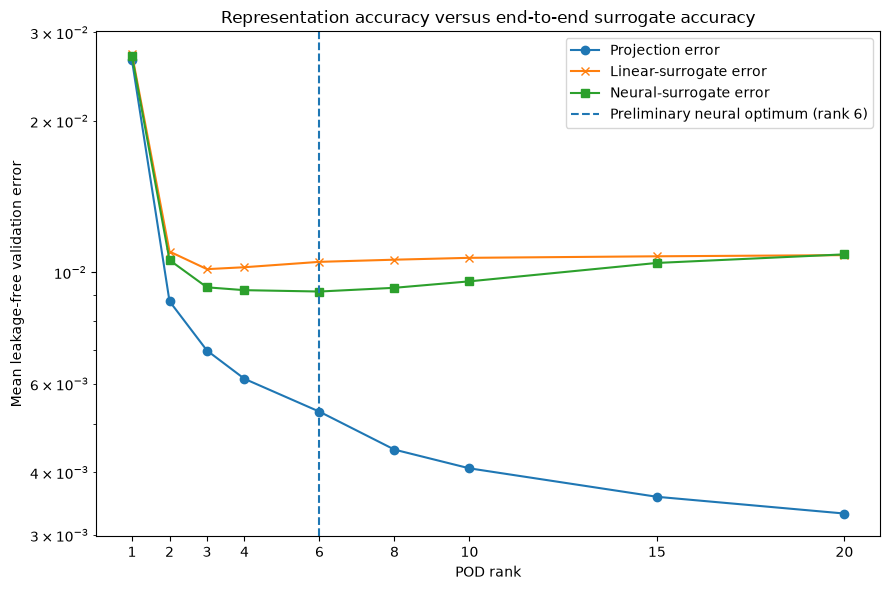


Saved rank-error figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_rank_surrogate_cv_errors.pdf


In [7]:
linear_detailed_path = (
    TABLE_DIR
    / "cg_phi_rank_linear_cv_detailed.csv"
)

neural_detailed_path = (
    TABLE_DIR
    / "cg_phi_rank_neural_cv_detailed.csv"
)

rank_summary_path = (
    TABLE_DIR
    / "cg_phi_rank_surrogate_cv_summary.csv"
)

linear_cross_validation_results.to_csv(
    linear_detailed_path,
    index=False,
)

neural_cross_validation_results.to_csv(
    neural_detailed_path,
    index=False,
)

combined_rank_summary.to_csv(
    rank_summary_path,
    index=False,
)

print("Saved detailed and summary tables:")
print(linear_detailed_path)
print(neural_detailed_path)
print(rank_summary_path)


plt.figure(figsize=(9, 6))

plt.semilogy(
    combined_rank_summary["rank"],
    combined_rank_summary[
        "mean_projection_error"
    ],
    marker="o",
    label="Projection error",
)

plt.semilogy(
    combined_rank_summary["rank"],
    combined_rank_summary[
        "linear_mean_error"
    ],
    marker="x",
    label="Linear-surrogate error",
)

plt.semilogy(
    combined_rank_summary["rank"],
    combined_rank_summary[
        "neural_mean_error"
    ],
    marker="s",
    label="Neural-surrogate error",
)

plt.axvline(
    preliminary_best_rank,
    linestyle="--",
    label=(
        "Preliminary neural optimum "
        f"(rank {preliminary_best_rank})"
    ),
)

plt.xticks(
    candidate_ranks
)

plt.xlabel("POD rank")
plt.ylabel("Mean leakage-free validation error")
plt.title(
    "Representation accuracy versus "
    "end-to-end surrogate accuracy"
)

plt.legend()
plt.tight_layout()

rank_error_figure_path = (
    FIGURE_DIR
    / "cg_phi_rank_surrogate_cv_errors.pdf"
)

plt.savefig(
    rank_error_figure_path,
    bbox_inches="tight",
)

plt.show()

print("\nSaved rank-error figure:")
print(rank_error_figure_path)

In [8]:
robust_candidate_ranks = np.array(
    [
        3,
        4,
        6,
        8,
        10,
    ],
    dtype=int,
)

repeat_seeds = [
    11,
    23,
    37,
    53,
    71,
]

repeated_seed_records = []

total_repeated_models = (
    robust_candidate_ranks.size
    * len(repeat_seeds)
    * number_of_folds
)

completed_repeated_models = 0

for seed in repeat_seeds:
    for rank in robust_candidate_ranks:
        all_rank_errors = []

        for fold in fold_data:
            basis = fold[
                "modes"
            ][
                :,
                :rank,
            ]

            fitting_coefficients = (
                basis.T
                @ fold[
                    "centred_fitting_snapshots"
                ]
            )

            predicted_coefficients = (
                predict_neural_coefficients(
                    fitting_parameters=fold[
                        "fitting_parameters"
                    ],
                    fitting_coefficients=(
                        fitting_coefficients
                    ),
                    query_parameters=fold[
                        "validation_parameters"
                    ],
                    random_state=(
                        seed
                        + 100 * fold["fold_number"]
                        + rank
                    ),
                )
            )

            predicted_snapshots = (
                fold["mean_snapshot"]
                + basis
                @ predicted_coefficients
            )

            fold_errors = (
                relative_snapshot_errors(
                    fold[
                        "validation_snapshots"
                    ],
                    predicted_snapshots,
                )
            )

            all_rank_errors.append(
                fold_errors
            )

            completed_repeated_models += 1

        repeated_errors = np.concatenate(
            all_rank_errors
        )

        repeated_seed_records.append(
            {
                "seed": seed,
                "rank": int(rank),
                "mean_validation_error": float(
                    repeated_errors.mean()
                ),
                "median_validation_error": float(
                    np.median(
                        repeated_errors
                    )
                ),
                "maximum_validation_error": float(
                    repeated_errors.max()
                ),
                "standard_deviation_error": float(
                    repeated_errors.std()
                ),
            }
        )

        print(
            f"Seed {seed}, rank {rank}: "
            f"mean error = "
            f"{repeated_errors.mean():.6e}"
        )

print(
    "\nCompleted neural models:",
    completed_repeated_models,
    "of",
    total_repeated_models,
)

repeated_seed_results = pd.DataFrame(
    repeated_seed_records
)

display(
    repeated_seed_results
)

Seed 11, rank 3: mean error = 9.249076e-03
Seed 11, rank 4: mean error = 9.186560e-03
Seed 11, rank 6: mean error = 9.260862e-03
Seed 11, rank 8: mean error = 9.285699e-03
Seed 11, rank 10: mean error = 9.561830e-03
Seed 23, rank 3: mean error = 9.352196e-03
Seed 23, rank 4: mean error = 9.196220e-03
Seed 23, rank 6: mean error = 9.157511e-03
Seed 23, rank 8: mean error = 9.311244e-03
Seed 23, rank 10: mean error = 1.013071e-02
Seed 37, rank 3: mean error = 9.237030e-03
Seed 37, rank 4: mean error = 9.308417e-03
Seed 37, rank 6: mean error = 9.069281e-03
Seed 37, rank 8: mean error = 9.232107e-03
Seed 37, rank 10: mean error = 9.586522e-03
Seed 53, rank 3: mean error = 9.278406e-03
Seed 53, rank 4: mean error = 9.288028e-03
Seed 53, rank 6: mean error = 9.152267e-03
Seed 53, rank 8: mean error = 9.263268e-03
Seed 53, rank 10: mean error = 9.474176e-03
Seed 71, rank 3: mean error = 9.232997e-03
Seed 71, rank 4: mean error = 9.102813e-03
Seed 71, rank 6: mean error = 9.471563e-03
Seed 71

,seed,rank,mean_validation_error,median_validation_error,maximum_validation_error,standard_deviation_error
0,11,3,0.009249,0.008789,0.020450,0.003378
1,11,4,0.009187,0.008497,0.020539,0.003462
2,11,6,0.009261,0.008223,0.020731,0.003497
3,11,8,0.009286,0.008630,0.020515,0.003210
4,11,10,0.009562,0.008484,0.021978,0.003756
5,23,3,0.009352,0.008890,0.020403,0.003511
6,23,4,0.009196,0.008618,0.020354,0.003402
7,23,6,0.009158,0.008554,0.022080,0.003293
8,23,8,0.009311,0.008808,0.020254,0.003276
9,23,10,0.010131,0.008449,0.029217,0.004712


In [9]:
robust_rank_summary = (
    repeated_seed_results
    .groupby(
        "rank",
        as_index=False,
    )
    .agg(
        number_of_seeds=(
            "seed",
            "nunique",
        ),
        mean_cv_error=(
            "mean_validation_error",
            "mean",
        ),
        median_cv_error=(
            "mean_validation_error",
            "median",
        ),
        minimum_cv_error=(
            "mean_validation_error",
            "min",
        ),
        maximum_cv_error=(
            "mean_validation_error",
            "max",
        ),
        standard_deviation_across_seeds=(
            "mean_validation_error",
            "std",
        ),
        worst_case_error=(
            "maximum_validation_error",
            "max",
        ),
    )
)

robust_rank_summary[
    "standard_error"
] = (
    robust_rank_summary[
        "standard_deviation_across_seeds"
    ]
    / np.sqrt(
        robust_rank_summary[
            "number_of_seeds"
        ]
    )
)

best_mean_row = robust_rank_summary.loc[
    robust_rank_summary[
        "mean_cv_error"
    ].idxmin()
]

best_mean_rank = int(
    best_mean_row["rank"]
)

best_mean_error = float(
    best_mean_row["mean_cv_error"]
)

best_standard_error = float(
    best_mean_row["standard_error"]
)

one_standard_error_threshold = (
    best_mean_error
    + best_standard_error
)

eligible_ranks = robust_rank_summary.loc[
    robust_rank_summary[
        "mean_cv_error"
    ]
    <= one_standard_error_threshold,
    "rank",
]

one_standard_error_rank = int(
    eligible_ranks.min()
)

print("Repeated-seed rank stability")
print("----------------------------")

display(
    robust_rank_summary
)

print(
    "\nRank with lowest average error:",
    best_mean_rank,
)

print(
    "Lowest average error:",
    f"{best_mean_error:.6e}",
)

print(
    "One-standard-error threshold:",
    f"{one_standard_error_threshold:.6e}",
)

print(
    "Smallest rank within one standard error:",
    one_standard_error_rank,
)

if one_standard_error_rank < best_mean_rank:
    print(
        "\nThe one-standard-error rule favours the "
        "smaller model because its performance is "
        "statistically similar to the minimum-error rank."
    )
else:
    print(
        "\nThe minimum-error rank also satisfies the "
        "one-standard-error simplicity criterion."
    )

Repeated-seed rank stability
----------------------------


,rank,number_of_seeds,mean_cv_error,median_cv_error,minimum_cv_error,maximum_cv_error,standard_deviation_across_seeds,worst_case_error,standard_error
0,3,5,0.009270,0.009249,0.009233,0.009352,0.000049,0.020828,0.000022
1,4,5,0.009216,0.009196,0.009103,0.009308,0.000083,0.020573,0.000037
2,6,5,0.009222,0.009158,0.009069,0.009472,0.000155,0.023184,0.000069
3,8,5,0.009309,0.009286,0.009232,0.009452,0.000085,0.021408,0.000038
4,10,5,0.009681,0.009587,0.009474,0.010131,0.000259,0.029217,0.000116



Rank with lowest average error: 4
Lowest average error: 9.216408e-03
One-standard-error threshold: 9.253688e-03
Smallest rank within one standard error: 4

The minimum-error rank also satisfies the one-standard-error simplicity criterion.


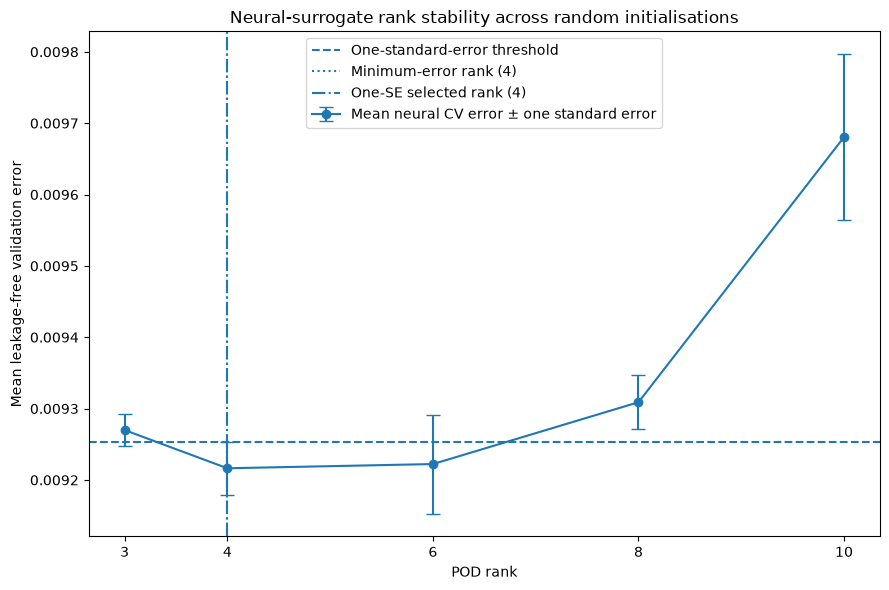

Saved repeated-seed results:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_rank_neural_repeated_seed_results.csv

Saved robust rank summary:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_rank_neural_robust_summary.csv

Saved stability figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_rank_neural_seed_stability.pdf


In [10]:
plt.figure(
    figsize=(9, 6)
)

plt.errorbar(
    robust_rank_summary["rank"],
    robust_rank_summary[
        "mean_cv_error"
    ],
    yerr=robust_rank_summary[
        "standard_error"
    ],
    marker="o",
    capsize=5,
    label=(
        "Mean neural CV error "
        "± one standard error"
    ),
)

plt.axhline(
    one_standard_error_threshold,
    linestyle="--",
    label="One-standard-error threshold",
)

plt.axvline(
    best_mean_rank,
    linestyle=":",
    label=(
        "Minimum-error rank "
        f"({best_mean_rank})"
    ),
)

plt.axvline(
    one_standard_error_rank,
    linestyle="-.",
    label=(
        "One-SE selected rank "
        f"({one_standard_error_rank})"
    ),
)

plt.xticks(
    robust_candidate_ranks
)

plt.xlabel("POD rank")
plt.ylabel("Mean leakage-free validation error")

plt.title(
    "Neural-surrogate rank stability "
    "across random initialisations"
)

plt.legend()
plt.tight_layout()

robust_rank_figure_path = (
    FIGURE_DIR
    / "cg_phi_rank_neural_seed_stability.pdf"
)

plt.savefig(
    robust_rank_figure_path,
    bbox_inches="tight",
)

plt.show()


repeated_results_path = (
    TABLE_DIR
    / "cg_phi_rank_neural_repeated_seed_results.csv"
)

robust_summary_path = (
    TABLE_DIR
    / "cg_phi_rank_neural_robust_summary.csv"
)

repeated_seed_results.to_csv(
    repeated_results_path,
    index=False,
)

robust_rank_summary.to_csv(
    robust_summary_path,
    index=False,
)

print("Saved repeated-seed results:")
print(repeated_results_path)

print("\nSaved robust rank summary:")
print(robust_summary_path)

print("\nSaved stability figure:")
print(robust_rank_figure_path)

In [11]:
selected_rank = int(
    one_standard_error_rank
)

selected_random_state = 42

full_mean_snapshot = (
    train_snapshot_matrix.mean(
        axis=1,
        keepdims=True,
    )
)

full_centred_training_snapshots = (
    train_snapshot_matrix
    - full_mean_snapshot
)

(
    full_modes,
    full_singular_values,
    full_right_vectors,
) = np.linalg.svd(
    full_centred_training_snapshots,
    full_matrices=False,
)

selected_basis = full_modes[
    :,
    :selected_rank,
]

selected_training_coefficients = (
    selected_basis.T
    @ full_centred_training_snapshots
)

full_cumulative_energy = np.cumsum(
    full_singular_values**2
) / np.sum(
    full_singular_values**2
)

selected_captured_energy = float(
    full_cumulative_energy[
        selected_rank - 1
    ]
)

centred_test_snapshots = (
    test_snapshot_matrix
    - full_mean_snapshot
)

selected_projected_test_coefficients = (
    selected_basis.T
    @ centred_test_snapshots
)

selected_projected_test_snapshots = (
    full_mean_snapshot
    + selected_basis
    @ selected_projected_test_coefficients
)

selected_linear_test_coefficients = (
    predict_linear_coefficients(
        fitting_parameters=train_parameters,
        fitting_coefficients=(
            selected_training_coefficients
        ),
        query_parameters=test_parameters,
    )
)

selected_linear_test_snapshots = (
    full_mean_snapshot
    + selected_basis
    @ selected_linear_test_coefficients
)

selected_neural_test_coefficients = (
    predict_neural_coefficients(
        fitting_parameters=train_parameters,
        fitting_coefficients=(
            selected_training_coefficients
        ),
        query_parameters=test_parameters,
        random_state=selected_random_state,
    )
)

selected_neural_test_snapshots = (
    full_mean_snapshot
    + selected_basis
    @ selected_neural_test_coefficients
)

orthonormality_error = np.linalg.norm(
    selected_basis.T
    @ selected_basis
    - np.eye(selected_rank)
)

print("Locked model")
print("------------")

print(
    "Selected POD rank:",
    selected_rank,
)

print(
    "Captured fluctuation energy:",
    f"{selected_captured_energy:.8f}",
)

print(
    "Training coefficient matrix:",
    selected_training_coefficients.shape,
)

print(
    "Neural test coefficient matrix:",
    selected_neural_test_coefficients.shape,
)

print(
    "Basis orthonormality error:",
    f"{orthonormality_error:.6e}",
)

assert selected_rank == 4

assert selected_basis.shape == (
    10000,
    selected_rank,
)

assert selected_neural_test_snapshots.shape == (
    10000,
    10,
)

assert orthonormality_error < 1e-10

print("\nLocked rank-4 model checks passed.")

Locked model
------------
Selected POD rank: 4
Captured fluctuation energy: 0.99856063
Training coefficient matrix: (4, 100)
Neural test coefficient matrix: (4, 10)
Basis orthonormality error: 4.788175e-15

Locked rank-4 model checks passed.


In [12]:
selected_projection_errors = (
    relative_snapshot_errors(
        test_snapshot_matrix,
        selected_projected_test_snapshots,
    )
)

selected_linear_errors = (
    relative_snapshot_errors(
        test_snapshot_matrix,
        selected_linear_test_snapshots,
    )
)

selected_neural_errors = (
    relative_snapshot_errors(
        test_snapshot_matrix,
        selected_neural_test_snapshots,
    )
)

selected_test_results = pd.DataFrame(
    {
        "size_ratio": test_parameters,
        "rank_4_projection_error": (
            selected_projection_errors
        ),
        "rank_4_linear_error": (
            selected_linear_errors
        ),
        "rank_4_neural_error": (
            selected_neural_errors
        ),
        "rank_4_neural_excess_error": (
            selected_neural_errors
            - selected_projection_errors
        ),
    }
)

selected_test_summary = pd.DataFrame(
    [
        {
            "model": "rank_4_projection",
            "mean_test_error": (
                selected_projection_errors.mean()
            ),
            "median_test_error": np.median(
                selected_projection_errors
            ),
            "maximum_test_error": (
                selected_projection_errors.max()
            ),
        },
        {
            "model": "rank_4_linear",
            "mean_test_error": (
                selected_linear_errors.mean()
            ),
            "median_test_error": np.median(
                selected_linear_errors
            ),
            "maximum_test_error": (
                selected_linear_errors.max()
            ),
        },
        {
            "model": "rank_4_neural",
            "mean_test_error": (
                selected_neural_errors.mean()
            ),
            "median_test_error": np.median(
                selected_neural_errors
            ),
            "maximum_test_error": (
                selected_neural_errors.max()
            ),
        },
    ]
)

rank_6_results_path = (
    TABLE_DIR
    / "cg_phi_neural_surrogate_comparison.csv"
)

rank_6_results = None

if rank_6_results_path.exists():
    rank_6_results = pd.read_csv(
        rank_6_results_path
    )

    assert np.allclose(
        rank_6_results["size_ratio"],
        test_parameters,
    )

    rank_6_neural_errors = (
        rank_6_results[
            "neural_network_error"
        ].to_numpy()
    )

    selected_test_results[
        "rank_6_neural_error"
    ] = rank_6_neural_errors

    selected_test_summary.loc[
        len(selected_test_summary)
    ] = {
        "model": "rank_6_neural_previous",
        "mean_test_error": (
            rank_6_neural_errors.mean()
        ),
        "median_test_error": np.median(
            rank_6_neural_errors
        ),
        "maximum_test_error": (
            rank_6_neural_errors.max()
        ),
    }

print("Untouched test-set results")
print("--------------------------")

display(
    selected_test_summary
)

print(
    "Rank-4 neural mean test error:",
    f"{selected_neural_errors.mean():.6e}",
)

print(
    "Rank-4 neural maximum test error:",
    f"{selected_neural_errors.max():.6e}",
)

print(
    "Mean excess above rank-4 projection floor:",
    f"{(
        selected_neural_errors
        - selected_projection_errors
    ).mean():.6e}",
)

if rank_6_results is not None:
    rank_4_minus_rank_6 = (
        selected_neural_errors.mean()
        - rank_6_neural_errors.mean()
    )

    print(
        "Rank-4 minus rank-6 mean test error:",
        f"{rank_4_minus_rank_6:.6e}",
    )

display(
    selected_test_results
)

selected_test_results_path = (
    TABLE_DIR
    / "cg_phi_selected_rank4_test_results.csv"
)

selected_test_summary_path = (
    TABLE_DIR
    / "cg_phi_selected_rank4_test_summary.csv"
)

selected_test_results.to_csv(
    selected_test_results_path,
    index=False,
)

selected_test_summary.to_csv(
    selected_test_summary_path,
    index=False,
)

print("\nSaved detailed test results:")
print(selected_test_results_path)

print("\nSaved test summary:")
print(selected_test_summary_path)

Untouched test-set results
--------------------------


,model,mean_test_error,median_test_error,maximum_test_error
0,rank_4_projection,0.005587,0.005327,0.008067
1,rank_4_linear,0.009585,0.009910,0.017728
2,rank_4_neural,0.009273,0.008160,0.015276
3,rank_6_neural_previous,0.008393,0.008058,0.013042


Rank-4 neural mean test error: 9.273374e-03
Rank-4 neural maximum test error: 1.527620e-02
Mean excess above rank-4 projection floor: 3.686814e-03
Rank-4 minus rank-6 mean test error: 8.803895e-04


,size_ratio,rank_4_projection_error,rank_4_linear_error,rank_4_neural_error,rank_4_neural_excess_error,rank_6_neural_error
0,1.0625,0.007285,0.017728,0.015276,0.007991,0.013042
1,1.1250,0.008067,0.010802,0.012247,0.004180,0.012361
2,1.2500,0.005675,0.009037,0.007729,0.002054,0.008708
3,1.3125,0.005670,0.010784,0.008038,0.002368,0.008648
4,1.3750,0.004647,0.010832,0.010357,0.005710,0.007468
5,1.5000,0.005587,0.012224,0.012675,0.007088,0.010770
6,1.5625,0.005068,0.007651,0.007740,0.002673,0.005838
7,1.6250,0.004884,0.005649,0.008282,0.003398,0.007464
8,1.7500,0.004442,0.005253,0.004860,0.000418,0.004777
9,1.8750,0.004541,0.005889,0.005530,0.000989,0.004855



Saved detailed test results:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_selected_rank4_test_results.csv

Saved test summary:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_selected_rank4_test_summary.csv


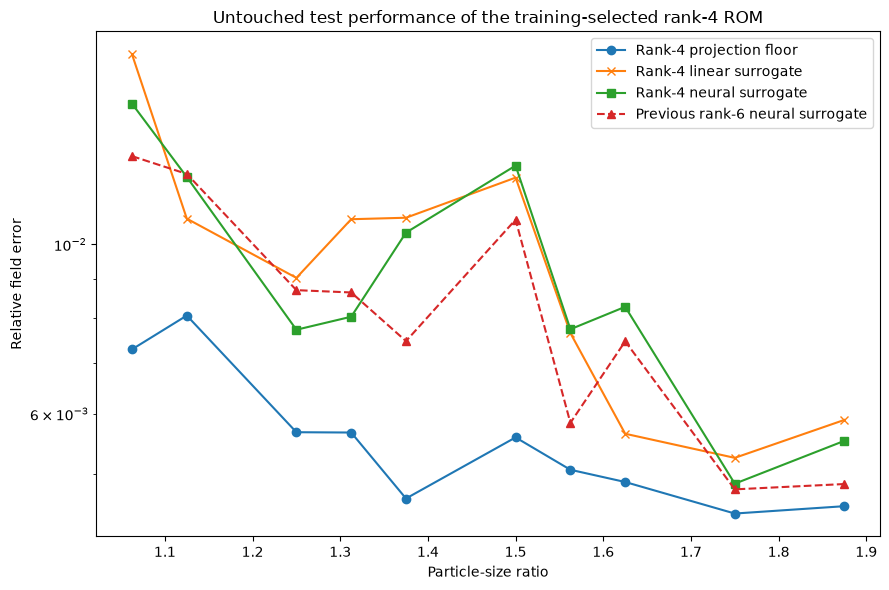

Saved test-error figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_selected_rank4_test_errors.pdf


In [13]:
plt.figure(
    figsize=(9, 6)
)

plt.semilogy(
    test_parameters,
    selected_projection_errors,
    marker="o",
    label="Rank-4 projection floor",
)

plt.semilogy(
    test_parameters,
    selected_linear_errors,
    marker="x",
    label="Rank-4 linear surrogate",
)

plt.semilogy(
    test_parameters,
    selected_neural_errors,
    marker="s",
    label="Rank-4 neural surrogate",
)

if rank_6_results is not None:
    plt.semilogy(
        test_parameters,
        rank_6_neural_errors,
        marker="^",
        linestyle="--",
        label="Previous rank-6 neural surrogate",
    )

plt.xlabel(
    "Particle-size ratio"
)

plt.ylabel(
    "Relative field error"
)

plt.title(
    "Untouched test performance of the "
    "training-selected rank-4 ROM"
)

plt.legend()
plt.tight_layout()

selected_test_figure_path = (
    FIGURE_DIR
    / "cg_phi_selected_rank4_test_errors.pdf"
)

plt.savefig(
    selected_test_figure_path,
    bbox_inches="tight",
)

plt.show()

print("Saved test-error figure:")
print(selected_test_figure_path)

In [14]:
x_spacing = float(
    np.mean(
        np.diff(x_grid)
    )
)

z_spacing = float(
    np.mean(
        np.diff(z_grid)
    )
)

grid_cell_area = (
    x_spacing
    * z_spacing
)

selected_diagnostic_records = []

for test_index, parameter in enumerate(
    test_parameters
):
    exact_snapshot = test_snapshot_matrix[
        :,
        test_index,
    ]

    predicted_snapshot = (
        selected_neural_test_snapshots[
            :,
            test_index,
        ]
    )

    exact_integrated_volume = (
        exact_snapshot.sum()
        * grid_cell_area
    )

    predicted_integrated_volume = (
        predicted_snapshot.sum()
        * grid_cell_area
    )

    relative_volume_error = (
        abs(
            predicted_integrated_volume
            - exact_integrated_volume
        )
        / abs(
            exact_integrated_volume
        )
    )

    selected_diagnostic_records.append(
        {
            "size_ratio": float(
                parameter
            ),
            "relative_field_error": float(
                selected_neural_errors[
                    test_index
                ]
            ),
            "projection_error": float(
                selected_projection_errors[
                    test_index
                ]
            ),
            "exact_integrated_volume": float(
                exact_integrated_volume
            ),
            "predicted_integrated_volume": float(
                predicted_integrated_volume
            ),
            "relative_volume_error": float(
                relative_volume_error
            ),
            "predicted_minimum": float(
                predicted_snapshot.min()
            ),
            "predicted_maximum": float(
                predicted_snapshot.max()
            ),
            "fraction_below_zero": float(
                np.mean(
                    predicted_snapshot < 0.0
                )
            ),
            "fraction_below_minus_1e_6": float(
                np.mean(
                    predicted_snapshot < -1e-6
                )
            ),
            "fraction_below_minus_1e_5": float(
                np.mean(
                    predicted_snapshot < -1e-5
                )
            ),
            "fraction_above_one": float(
                np.mean(
                    predicted_snapshot > 1.0
                )
            ),
        }
    )

selected_rank_diagnostics = pd.DataFrame(
    selected_diagnostic_records
)

print("Selected rank-4 physical diagnostics")
print("------------------------------------")

print(
    "Mean relative field error:",
    f"{selected_rank_diagnostics[
        'relative_field_error'
    ].mean():.6e}",
)

print(
    "Maximum relative field error:",
    f"{selected_rank_diagnostics[
        'relative_field_error'
    ].max():.6e}",
)

print(
    "Mean integrated-volume error:",
    f"{selected_rank_diagnostics[
        'relative_volume_error'
    ].mean():.6e}",
)

print(
    "Maximum integrated-volume error:",
    f"{selected_rank_diagnostics[
        'relative_volume_error'
    ].max():.6e}",
)

print(
    "Minimum predicted value:",
    f"{selected_rank_diagnostics[
        'predicted_minimum'
    ].min():.6e}",
)

print(
    "Maximum predicted value:",
    f"{selected_rank_diagnostics[
        'predicted_maximum'
    ].max():.6e}",
)

print(
    "Largest fraction below -1e-6:",
    f"{selected_rank_diagnostics[
        'fraction_below_minus_1e_6'
    ].max():.6e}",
)

print(
    "Largest fraction below -1e-5:",
    f"{selected_rank_diagnostics[
        'fraction_below_minus_1e_5'
    ].max():.6e}",
)

print(
    "Largest fraction above one:",
    f"{selected_rank_diagnostics[
        'fraction_above_one'
    ].max():.6e}",
)

selected_diagnostics_path = (
    TABLE_DIR
    / "cg_phi_selected_rank4_diagnostics.csv"
)

selected_rank_diagnostics.to_csv(
    selected_diagnostics_path,
    index=False,
)

print("\nSaved diagnostics:")
print(selected_diagnostics_path)

display(
    selected_rank_diagnostics
)

Selected rank-4 physical diagnostics
------------------------------------
Mean relative field error: 9.273374e-03
Maximum relative field error: 1.527620e-02
Mean integrated-volume error: 2.892869e-05
Maximum integrated-volume error: 8.788251e-05
Minimum predicted value: -1.598746e-06
Maximum predicted value: 5.375315e-01
Largest fraction below -1e-6: 1.400000e-03
Largest fraction below -1e-5: 0.000000e+00
Largest fraction above one: 0.000000e+00

Saved diagnostics:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_selected_rank4_diagnostics.csv


,size_ratio,relative_field_error,projection_error,exact_integrated_volume,predicted_integrated_volume,relative_volume_error,predicted_minimum,predicted_maximum,fraction_below_zero,fraction_below_minus_1e_6,fraction_below_minus_1e_5,fraction_above_one
0,1.0625,0.015276,0.007285,282.746837,282.771686,8.788251e-05,-6.886186e-07,0.345230,0.0431,0.0000,0.0,0.0
1,1.1250,0.012247,0.008067,282.756124,282.765902,3.458241e-05,-1.598746e-06,0.405342,0.0586,0.0014,0.0,0.0
2,1.2500,0.007729,0.005675,282.756398,282.759786,1.198229e-05,-6.689683e-07,0.476976,0.0451,0.0000,0.0,0.0
3,1.3125,0.008038,0.005670,282.763596,282.758162,1.921648e-05,-3.161741e-07,0.498761,0.0232,0.0000,0.0,0.0
4,1.3750,0.010357,0.004647,282.743538,282.757090,4.792900e-05,-3.982510e-07,0.513278,0.0254,0.0000,0.0,0.0
5,1.5000,0.012675,0.005587,282.768780,282.755857,4.570297e-05,-6.980212e-07,0.526142,0.0255,0.0000,0.0,0.0
6,1.5625,0.007740,0.005068,282.751839,282.755318,1.230407e-05,-6.784850e-07,0.529676,0.0235,0.0000,0.0,0.0
7,1.6250,0.008282,0.004884,282.752691,282.754728,7.204795e-06,-5.835220e-07,0.533137,0.0201,0.0000,0.0,0.0
8,1.7500,0.004860,0.004442,282.759771,282.753671,2.157603e-05,-1.515266e-07,0.537532,0.0123,0.0000,0.0,0.0
9,1.8750,0.005530,0.004541,282.753462,282.753205,9.063053e-07,-7.007360e-08,0.536196,0.0096,0.0000,0.0,0.0


In [15]:
import joblib


rank4_input_scaler = StandardScaler()
rank4_output_scaler = StandardScaler()

rank4_training_inputs = (
    rank4_input_scaler.fit_transform(
        train_parameters.reshape(-1, 1)
    )
)

rank4_training_outputs = (
    rank4_output_scaler.fit_transform(
        selected_training_coefficients.T
    )
)

rank4_neural_model = MLPRegressor(
    hidden_layer_sizes=(16,),
    activation="tanh",
    solver="lbfgs",
    alpha=0.1,
    max_iter=5000,
    random_state=selected_random_state,
)

rank4_neural_model.fit(
    rank4_training_inputs,
    rank4_training_outputs,
)


rank4_rom_package = {
    "model": rank4_neural_model,
    "input_scaler": rank4_input_scaler,
    "output_scaler": rank4_output_scaler,
    "mean_snapshot_vector": full_mean_snapshot,
    "pod_basis": selected_basis,
    "x_grid": x_grid,
    "z_grid": z_grid,
    "selected_rank": selected_rank,
    "captured_fluctuation_energy": (
        selected_captured_energy
    ),
    "training_parameters": train_parameters,
    "training_coefficients": (
        selected_training_coefficients
    ),
    "training_parameter_minimum": float(
        train_parameters.min()
    ),
    "training_parameter_maximum": float(
        train_parameters.max()
    ),
    "hidden_layer_sizes": (16,),
    "activation": "tanh",
    "solver": "lbfgs",
    "regularisation_alpha": 0.1,
    "random_state": selected_random_state,
    "selection_method": (
        "Five-fold leakage-free cross-validation "
        "with repeated random initialisations and "
        "the one-standard-error rule"
    ),
}

rank4_rom_package_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "cg_phi_rank4_neural_rom.joblib"
)

joblib.dump(
    rank4_rom_package,
    rank4_rom_package_path,
)


def predict_from_rom_package(
    package: dict,
    size_ratios,
):
    """
    Predict one or more complete volume-fraction fields using a
    saved ROM package.
    """
    parameter_values = np.asarray(
        size_ratios,
        dtype=float,
    )

    scalar_query = (
        parameter_values.ndim == 0
    )

    parameter_values = np.atleast_1d(
        parameter_values
    )

    minimum_parameter = float(
        package[
            "training_parameter_minimum"
        ]
    )

    maximum_parameter = float(
        package[
            "training_parameter_maximum"
        ]
    )

    outside_interval = (
        (parameter_values < minimum_parameter)
        | (parameter_values > maximum_parameter)
    )

    if np.any(outside_interval):
        raise ValueError(
            "At least one requested parameter lies outside "
            f"the supported interval [{minimum_parameter}, "
            f"{maximum_parameter}]."
        )

    scaled_inputs = package[
        "input_scaler"
    ].transform(
        parameter_values.reshape(-1, 1)
    )

    scaled_coefficients = np.asarray(
        package["model"].predict(
            scaled_inputs
        )
    )

    if scaled_coefficients.ndim == 1:
        scaled_coefficients = (
            scaled_coefficients.reshape(-1, 1)
        )

    predicted_coefficients = package[
        "output_scaler"
    ].inverse_transform(
        scaled_coefficients
    )

    predicted_snapshots = (
        package["mean_snapshot_vector"]
        + package["pod_basis"]
        @ predicted_coefficients.T
    )

    predicted_fields = (
        predicted_snapshots.T.reshape(
            parameter_values.size,
            package["z_grid"].size,
            package["x_grid"].size,
            order="C",
        )
    )

    if scalar_query:
        return predicted_fields[0]

    return predicted_fields


loaded_rank4_rom = joblib.load(
    rank4_rom_package_path
)

reloaded_rank4_test_fields = (
    predict_from_rom_package(
        loaded_rank4_rom,
        test_parameters,
    )
)

reloaded_rank4_test_snapshots = (
    reloaded_rank4_test_fields.reshape(
        test_parameters.size,
        -1,
        order="C",
    ).T
)

maximum_rank4_reload_difference = float(
    np.max(
        np.abs(
            reloaded_rank4_test_snapshots
            - selected_neural_test_snapshots
        )
    )
)

print("Saved rank-4 ROM:")
print(rank4_rom_package_path)

print(
    "Saved file size:",
    f"{rank4_rom_package_path.stat().st_size / 1024**2:.3f} MB",
)

print(
    "Maximum difference after reloading:",
    f"{maximum_rank4_reload_difference:.6e}",
)

assert loaded_rank4_rom[
    "selected_rank"
] == 4

assert np.allclose(
    reloaded_rank4_test_snapshots,
    selected_neural_test_snapshots,
    rtol=1e-12,
    atol=1e-12,
)

print("\nRank-4 ROM export verification passed.")

Saved rank-4 ROM:
/Users/rallen/Documents/msc-rom-particle-systems/data/processed/cg_phi_rank4_neural_rom.joblib
Saved file size: 0.394 MB
Maximum difference after reloading: 0.000000e+00

Rank-4 ROM export verification passed.


In [16]:
import time


rank6_rom_package_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "cg_phi_rank6_neural_rom.joblib"
)

if not rank6_rom_package_path.exists():
    raise FileNotFoundError(
        "The saved rank-6 ROM from Notebook 4 "
        "could not be found:\n"
        f"{rank6_rom_package_path}"
    )

loaded_rank6_rom = joblib.load(
    rank6_rom_package_path
)

reloaded_rank6_test_fields = (
    predict_from_rom_package(
        loaded_rank6_rom,
        test_parameters,
    )
)

reloaded_rank6_test_snapshots = (
    reloaded_rank6_test_fields.reshape(
        test_parameters.size,
        -1,
        order="C",
    ).T
)

rank6_package_test_errors = (
    relative_snapshot_errors(
        test_snapshot_matrix,
        reloaded_rank6_test_snapshots,
    )
)

maximum_rank6_error_difference = float(
    np.max(
        np.abs(
            rank6_package_test_errors
            - rank_6_neural_errors
        )
    )
)

print("Saved rank-6 ROM verification")
print("-----------------------------")

print(
    "Maximum difference from the previously "
    "reported rank-6 errors:",
    f"{maximum_rank6_error_difference:.6e}",
)

assert np.allclose(
    rank6_package_test_errors,
    rank_6_neural_errors,
    rtol=1e-10,
    atol=1e-12,
)

print("Rank-6 ROM verification passed.")


def benchmark_rom(
    package: dict,
    parameters: np.ndarray,
    repetitions: int = 20,
) -> dict:
    """
    Benchmark scalar online evaluations.

    Each timing includes coefficient prediction and reconstruction
    of the complete 10,000-point field.
    """
    parameters = np.asarray(
        parameters,
        dtype=float,
    )

    for parameter in parameters[:10]:
        predict_from_rom_package(
            package,
            float(parameter),
        )

    timing_values = []

    for _ in range(repetitions):
        for parameter in parameters:
            start_time = time.perf_counter()

            predict_from_rom_package(
                package,
                float(parameter),
            )

            end_time = time.perf_counter()

            timing_values.append(
                end_time - start_time
            )

    timing_values_ms = (
        1000.0
        * np.asarray(timing_values)
    )

    return {
        "number_of_predictions": int(
            timing_values_ms.size
        ),
        "mean_time_ms": float(
            timing_values_ms.mean()
        ),
        "median_time_ms": float(
            np.median(timing_values_ms)
        ),
        "percentile_95_time_ms": float(
            np.percentile(
                timing_values_ms,
                95,
            )
        ),
        "minimum_time_ms": float(
            timing_values_ms.min()
        ),
        "maximum_time_ms": float(
            timing_values_ms.max()
        ),
    }


benchmark_parameters = np.linspace(
    train_parameters.min(),
    train_parameters.max(),
    100,
)

rank4_timing = benchmark_rom(
    loaded_rank4_rom,
    benchmark_parameters,
)

rank6_timing = benchmark_rom(
    loaded_rank6_rom,
    benchmark_parameters,
)

timing_comparison = pd.DataFrame(
    [
        {
            "model": "rank_4_neural",
            **rank4_timing,
        },
        {
            "model": "rank_6_neural",
            **rank6_timing,
        },
    ]
)

print("\nOnline ROM timing comparison")
print("----------------------------")

display(
    timing_comparison
)

timing_comparison_path = (
    TABLE_DIR
    / "cg_phi_rank4_rank6_timing_comparison.csv"
)

timing_comparison.to_csv(
    timing_comparison_path,
    index=False,
)

print("Saved timing comparison:")
print(timing_comparison_path)

Saved rank-6 ROM verification
-----------------------------
Maximum difference from the previously reported rank-6 errors: 9.540979e-17
Rank-6 ROM verification passed.

Online ROM timing comparison
----------------------------


,model,number_of_predictions,mean_time_ms,median_time_ms,percentile_95_time_ms,minimum_time_ms,maximum_time_ms
0,rank_4_neural,2000,0.480860,0.421517,0.726460,0.407121,2.169024
1,rank_6_neural,2000,0.484581,0.426295,0.737749,0.408710,1.471558


Saved timing comparison:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_rank4_rank6_timing_comparison.csv


Final deployable-ROM comparison
-------------------------------


,model,model_role,pod_rank,captured_fluctuation_energy,mean_test_error,median_test_error,maximum_test_error,mean_volume_error,maximum_volume_error,median_online_time_ms,percentile_95_online_time_ms,package_size_mb
0,rank_4_neural,Training-selected parsimonious model,4,0.998561,0.009273,0.008160,0.015276,0.000029,0.000088,0.421517,0.726460,0.393718
1,rank_6_neural,Energy-threshold baseline and best observed te...,6,0.999029,0.008393,0.008058,0.013042,0.000029,0.000086,0.426295,0.737749,0.542737


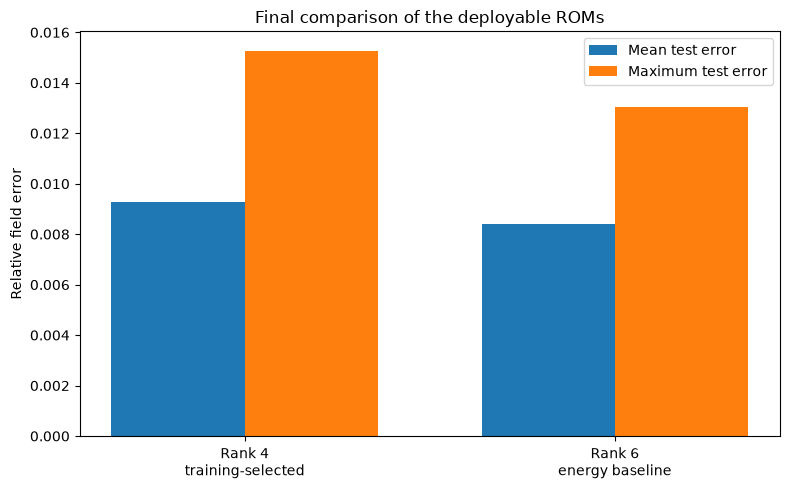


Saved model comparison:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_rank4_rank6_deployable_comparison.csv

Saved comparison figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_rank4_rank6_deployable_comparison.pdf

Saved reproducibility manifest:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_rom_reproducibility_manifest.json


In [17]:
import hashlib
import json
import platform

import sklearn


rank6_diagnostics_path = (
    TABLE_DIR
    / "cg_phi_neural_surrogate_diagnostics.csv"
)

rank6_summary_path = (
    TABLE_DIR
    / "cg_phi_rank6_neural_rom_summary.csv"
)

if not rank6_diagnostics_path.exists():
    raise FileNotFoundError(
        f"Missing rank-6 diagnostics:\n"
        f"{rank6_diagnostics_path}"
    )

if not rank6_summary_path.exists():
    raise FileNotFoundError(
        f"Missing rank-6 summary:\n"
        f"{rank6_summary_path}"
    )

rank6_diagnostics = pd.read_csv(
    rank6_diagnostics_path
)

rank6_summary = pd.read_csv(
    rank6_summary_path
).iloc[0]


final_deployable_model_comparison = pd.DataFrame(
    [
        {
            "model": "rank_4_neural",
            "model_role": (
                "Training-selected parsimonious model"
            ),
            "pod_rank": 4,
            "captured_fluctuation_energy": (
                selected_captured_energy
            ),
            "mean_test_error": (
                selected_neural_errors.mean()
            ),
            "median_test_error": np.median(
                selected_neural_errors
            ),
            "maximum_test_error": (
                selected_neural_errors.max()
            ),
            "mean_volume_error": (
                selected_rank_diagnostics[
                    "relative_volume_error"
                ].mean()
            ),
            "maximum_volume_error": (
                selected_rank_diagnostics[
                    "relative_volume_error"
                ].max()
            ),
            "median_online_time_ms": (
                rank4_timing[
                    "median_time_ms"
                ]
            ),
            "percentile_95_online_time_ms": (
                rank4_timing[
                    "percentile_95_time_ms"
                ]
            ),
            "package_size_mb": (
                rank4_rom_package_path.stat().st_size
                / 1024**2
            ),
        },
        {
            "model": "rank_6_neural",
            "model_role": (
                "Energy-threshold baseline and "
                "best observed test performance"
            ),
            "pod_rank": 6,
            "captured_fluctuation_energy": float(
                rank6_summary[
                    "captured_fluctuation_energy"
                ]
            ),
            "mean_test_error": (
                rank6_package_test_errors.mean()
            ),
            "median_test_error": np.median(
                rank6_package_test_errors
            ),
            "maximum_test_error": (
                rank6_package_test_errors.max()
            ),
            "mean_volume_error": (
                rank6_diagnostics[
                    "relative_volume_error"
                ].mean()
            ),
            "maximum_volume_error": (
                rank6_diagnostics[
                    "relative_volume_error"
                ].max()
            ),
            "median_online_time_ms": (
                rank6_timing[
                    "median_time_ms"
                ]
            ),
            "percentile_95_online_time_ms": (
                rank6_timing[
                    "percentile_95_time_ms"
                ]
            ),
            "package_size_mb": (
                rank6_rom_package_path.stat().st_size
                / 1024**2
            ),
        },
    ]
)

comparison_table_path = (
    TABLE_DIR
    / "cg_phi_rank4_rank6_deployable_comparison.csv"
)

final_deployable_model_comparison.to_csv(
    comparison_table_path,
    index=False,
)

print("Final deployable-ROM comparison")
print("-------------------------------")

display(
    final_deployable_model_comparison
)


bar_positions = np.arange(2)
bar_width = 0.36

figure, axis = plt.subplots(
    figsize=(8, 5)
)

axis.bar(
    bar_positions - bar_width / 2,
    final_deployable_model_comparison[
        "mean_test_error"
    ],
    width=bar_width,
    label="Mean test error",
)

axis.bar(
    bar_positions + bar_width / 2,
    final_deployable_model_comparison[
        "maximum_test_error"
    ],
    width=bar_width,
    label="Maximum test error",
)

axis.set_xticks(
    bar_positions
)

axis.set_xticklabels(
    [
        "Rank 4\ntraining-selected",
        "Rank 6\nenergy baseline",
    ]
)

axis.set_ylabel(
    "Relative field error"
)

axis.set_title(
    "Final comparison of the deployable ROMs"
)

axis.legend()
figure.tight_layout()

deployable_comparison_figure_path = (
    FIGURE_DIR
    / "cg_phi_rank4_rank6_deployable_comparison.pdf"
)

figure.savefig(
    deployable_comparison_figure_path,
    bbox_inches="tight",
)

plt.show()


def calculate_sha256(
    file_path: Path,
) -> str:
    """Calculate a SHA-256 checksum for a saved file."""
    checksum = hashlib.sha256()

    with file_path.open("rb") as file_handle:
        for block in iter(
            lambda: file_handle.read(1024 * 1024),
            b"",
        ):
            checksum.update(block)

    return checksum.hexdigest()


reproducibility_manifest = {
    "notebook": (
        "05_rank_and_surrogate_selection.ipynb"
    ),
    "python_version": (
        sys.version.split()[0]
    ),
    "platform": platform.platform(),
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "scikit_learn_version": (
        sklearn.__version__
    ),
    "joblib_version": joblib.__version__,
    "processed_dataset": str(
        PROCESSED_DATA_PATH.relative_to(
            PROJECT_ROOT
        )
    ),
    "training_case_count": int(
        train_parameters.size
    ),
    "test_case_count": int(
        test_parameters.size
    ),
    "cross_validation_folds": int(
        number_of_folds
    ),
    "candidate_ranks": (
        candidate_ranks.tolist()
    ),
    "repeated_initialisation_seeds": (
        repeat_seeds
    ),
    "test_set_status": (
        "Held out from rank-4 model selection, but "
        "previously examined for the rank-6 baseline"
    ),
    "rank_4_rom": {
        "path": str(
            rank4_rom_package_path.relative_to(
                PROJECT_ROOT
            )
        ),
        "sha256": calculate_sha256(
            rank4_rom_package_path
        ),
        "rank": 4,
        "random_state": (
            selected_random_state
        ),
        "selection_rule": (
            "Lowest repeated-seed CV error and "
            "one-standard-error rule"
        ),
    },
    "rank_6_rom": {
        "path": str(
            rank6_rom_package_path.relative_to(
                PROJECT_ROOT
            )
        ),
        "sha256": calculate_sha256(
            rank6_rom_package_path
        ),
        "rank": 6,
        "selection_rule": (
            "Approximately 99.9 percent "
            "fluctuation-energy threshold"
        ),
    },
}

manifest_path = (
    TABLE_DIR
    / "cg_phi_rom_reproducibility_manifest.json"
)

with manifest_path.open(
    "w",
    encoding="utf-8",
) as file_handle:
    json.dump(
        reproducibility_manifest,
        file_handle,
        indent=2,
    )

print("\nSaved model comparison:")
print(comparison_table_path)

print("\nSaved comparison figure:")
print(deployable_comparison_figure_path)

print("\nSaved reproducibility manifest:")
print(manifest_path)

In [18]:
from IPython.display import Markdown


rank4_cv_error = float(
    robust_rank_summary.loc[
        robust_rank_summary["rank"] == 4,
        "mean_cv_error",
    ].iloc[0]
)

rank6_cv_error = float(
    robust_rank_summary.loc[
        robust_rank_summary["rank"] == 6,
        "mean_cv_error",
    ].iloc[0]
)

rank4_test_error = float(
    selected_neural_errors.mean()
)

rank6_test_error = float(
    rank6_package_test_errors.mean()
)

rank4_maximum_error = float(
    selected_neural_errors.max()
)

rank6_maximum_error = float(
    rank6_package_test_errors.max()
)

rank4_mean_volume_error = float(
    selected_rank_diagnostics[
        "relative_volume_error"
    ].mean()
)

rank6_mean_volume_error = float(
    rank6_diagnostics[
        "relative_volume_error"
    ].mean()
)

final_conclusion_markdown = f"""
## Conclusions

This notebook examined the trade-off between POD representation accuracy and
end-to-end surrogate predictability.

A leakage-free five-fold cross-validation procedure was used. Within every
fold, the mean field and POD basis were calculated using only the fitting
simulations. The held-out validation fields therefore had no influence on
either the reduced basis or the coefficient surrogate.

Increasing the POD rank continually reduced projection error. However, the
end-to-end surrogate error did not decrease monotonically because the
higher-order POD coefficients became increasingly difficult to predict.

Repeated neural-network training across five random initialisations produced
mean validation errors of approximately:

- **{100 * rank4_cv_error:.4f}% at rank 4**;
- **{100 * rank6_cv_error:.4f}% at rank 6**.

Rank 4 achieved the lowest average repeated-seed validation error and was also
selected by the one-standard-error rule. It is therefore retained as the
training-selected parsimonious model.

On the held-out ten-case dataset:

- the rank-4 neural ROM achieved a mean error of
  **{100 * rank4_test_error:.4f}%** and a maximum error of
  **{100 * rank4_maximum_error:.4f}%**;
- the rank-6 neural ROM achieved a mean error of
  **{100 * rank6_test_error:.4f}%** and a maximum error of
  **{100 * rank6_maximum_error:.4f}%**.

The rank-4 test error closely matched its leakage-free validation estimate,
showing that the validation procedure provided a reliable estimate of its
generalisation performance. Rank 6 nevertheless achieved the lower observed
error on the available ten-case test set.

The two models therefore serve different roles:

- **rank 4** is the model selected solely from leakage-free training
  validation and model-parsimony considerations;
- **rank 6** is the energy-threshold baseline and gives the best observed
  performance on the available test cases.

The available results do not establish that one rank is universally superior.
The validation difference between ranks 4 and 6 is extremely small, while the
test set contains only ten cases and had previously been examined during the
rank-6 study. Both models should therefore be retained for external validation
on an independent dataset.

Both models preserve the integrated particle volume accurately. Their mean
relative integrated-volume errors are approximately
**{100 * rank4_mean_volume_error:.5f}%** for rank 4 and
**{100 * rank6_mean_volume_error:.5f}%** for rank 6. Neither model predicts
volume fractions above one, and the small negative values are negligible
numerical oscillations.

Both reduced-order models have been saved as verified deployable packages.
Reloading the rank-4 package reproduces its original predictions to numerical
precision, while the saved rank-6 package reproduces the previously reported
rank-6 errors. The median scalar online evaluation times are approximately
**{rank4_timing['median_time_ms']:.3f} ms** for rank 4 and
**{rank6_timing['median_time_ms']:.3f} ms** for rank 6. These timings include
neural coefficient prediction and reconstruction of the complete 10,000-point
field, but they are not yet presented as formal speed-ups relative to the
original particle simulations.

A reproducibility manifest records the software versions, model-selection
settings and SHA-256 checksums of both saved ROM packages.
"""

display(
    Markdown(
        final_conclusion_markdown
    )
)

conclusion_path = (
    TABLE_DIR
    / "cg_phi_rank_selection_conclusions.md"
)

conclusion_path.write_text(
    final_conclusion_markdown.strip()
    + "\n",
    encoding="utf-8",
)

print("Saved final conclusion:")
print(conclusion_path)


## Conclusions

This notebook examined the trade-off between POD representation accuracy and
end-to-end surrogate predictability.

A leakage-free five-fold cross-validation procedure was used. Within every
fold, the mean field and POD basis were calculated using only the fitting
simulations. The held-out validation fields therefore had no influence on
either the reduced basis or the coefficient surrogate.

Increasing the POD rank continually reduced projection error. However, the
end-to-end surrogate error did not decrease monotonically because the
higher-order POD coefficients became increasingly difficult to predict.

Repeated neural-network training across five random initialisations produced
mean validation errors of approximately:

- **0.9216% at rank 4**;
- **0.9222% at rank 6**.

Rank 4 achieved the lowest average repeated-seed validation error and was also
selected by the one-standard-error rule. It is therefore retained as the
training-selected parsimonious model.

On the held-out ten-case dataset:

- the rank-4 neural ROM achieved a mean error of
  **0.9273%** and a maximum error of
  **1.5276%**;
- the rank-6 neural ROM achieved a mean error of
  **0.8393%** and a maximum error of
  **1.3042%**.

The rank-4 test error closely matched its leakage-free validation estimate,
showing that the validation procedure provided a reliable estimate of its
generalisation performance. Rank 6 nevertheless achieved the lower observed
error on the available ten-case test set.

The two models therefore serve different roles:

- **rank 4** is the model selected solely from leakage-free training
  validation and model-parsimony considerations;
- **rank 6** is the energy-threshold baseline and gives the best observed
  performance on the available test cases.

The available results do not establish that one rank is universally superior.
The validation difference between ranks 4 and 6 is extremely small, while the
test set contains only ten cases and had previously been examined during the
rank-6 study. Both models should therefore be retained for external validation
on an independent dataset.

Both models preserve the integrated particle volume accurately. Their mean
relative integrated-volume errors are approximately
**0.00289%** for rank 4 and
**0.00288%** for rank 6. Neither model predicts
volume fractions above one, and the small negative values are negligible
numerical oscillations.

Both reduced-order models have been saved as verified deployable packages.
Reloading the rank-4 package reproduces its original predictions to numerical
precision, while the saved rank-6 package reproduces the previously reported
rank-6 errors. The median scalar online evaluation times are approximately
**0.422 ms** for rank 4 and
**0.426 ms** for rank 6. These timings include
neural coefficient prediction and reconstruction of the complete 10,000-point
field, but they are not yet presented as formal speed-ups relative to the
original particle simulations.

A reproducibility manifest records the software versions, model-selection
settings and SHA-256 checksums of both saved ROM packages.


Saved final conclusion:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_rank_selection_conclusions.md
